# Session 3, Notebook 3: Loss Balancing for Multi-Component Residuals

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 1, 13:30-14:25, Neural architecture search and loss balancing
**Slides:** `03b_Loss_Balancing.pdf`
**Author:** Simon Scheidegger (HEC, University of Lausanne)

In [1]:
RUN_MODE = "teaching"   # one of: "smoke", "teaching", "production"
SEED = 0

A DEQN never minimizes one residual. It minimizes

$$J(\theta) \;=\; \sum_{k=1}^{M} \omega_k \, \mathcal{L}_k(\theta),$$

where the components are Euler equations, budget constraints, market clearing and complementarity
conditions. They carry **different units**, so they arrive at the optimizer with different
magnitudes, and the gradient follows the loudest one.

This notebook runs one controlled experiment, measures the gradient each component actually
contributes, and then repeats the measurement on a deep equilibrium net.

| Question | Section |
|:--|:--|
| Is the failure caused by the *scales*, or by the components being different problems? | 2 (control) and 3 |
| Does dividing each residual by its own scale fix it? | 4 |
| What does inverse-loss weighting actually do to the gradients? | 5 |
| What can ReLoBRaLo do, and what limits it? | 6 |
| What does the same measurement show on a DEQN? | 7 |

The headline: on a scale gap that sits in the units, non-dimensionalization beats every adaptive
rule by two orders of magnitude. The adaptive rules are for the gap that remains after that.

In [2]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

rcParams.update({
    "figure.dpi":        120,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "font.family":       "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

C = {"A": "#2a9d8f", "B": "#e76f51", "C": "#264653"}       # the three components
M_COL = {"equal": "#6c757d", "normalized": "#457b9d", "inverse": "#e9c46a",
         "relobralo": "#9d4edd", "relobralo_step": "#f4a261"}

# The figures used in the slide deck are written by the teaching run.
FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = (RUN_MODE == "teaching")

def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
        fig.savefig(FIG_DIR / f"{name}.png", dpi=180, bbox_inches="tight")

T_NOTEBOOK = time.perf_counter()
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow {tf.__version__} | RUN_MODE = {RUN_MODE} | SAVE_FIGS = {SAVE_FIGS}")

2026-09-09 11:06:51.342685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788944811.371905  641141 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788944811.383872  641141 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 11:06:51.417082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0 | RUN_MODE = teaching | SAVE_FIGS = True


---
## 1. Three residual families, one shared trunk

We stand in for the residuals of an economic model with three Genz test functions on $[0,1]^2$,
the standard tunable family for benchmarking approximation methods:

$$f_A = \text{Gaussian}, \qquad f_B = \text{oscillatory}, \qquad f_C = \text{continuous (kinked)}.$$

One network with a shared trunk and three linear heads predicts all three at once, like a DEQN
with one policy network and several equilibrium conditions.

The experiment has **one knob**: the scale each target is multiplied by. Shapes, data, architecture,
optimizer, budget and seed are held fixed, which is what lets us attribute the failure in Section 3
to the scales and to nothing else.

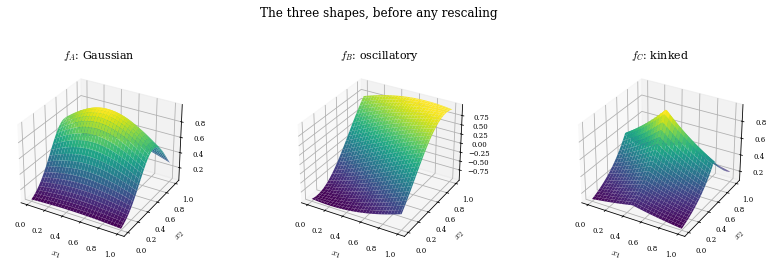

f_A: range [+0.049, +1.000],  mean |f| = 0.550
f_B: range [-1.000, +1.000],  mean |f| = 0.576
f_C: range [+0.106, +0.976],  mean |f| = 0.413


In [3]:
d = 2

def genz_gaussian(X, c, w):    return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))
def genz_oscillatory(X, c, w): return np.cos(2.0 * np.pi * w[0] + X @ c)
def genz_continuous(X, c, w):  return np.exp(-np.sum(c * np.abs(X - w), axis=1))

_rng    = np.random.RandomState(7)
c_param = _rng.uniform(1.0, 3.0, size=d)
w_param = _rng.uniform(0.2, 0.8, size=d)

SHAPES = [lambda X: genz_gaussian(X, c_param, w_param),
          lambda X: genz_oscillatory(X, c_param, w_param),
          lambda X: genz_continuous(X, c_param, w_param)]
NAMES  = ["A (Gaussian)", "B (oscillatory)", "C (kinked)"]

# The one knob.
SCALES_FLAT  = np.array([1.0, 1.0, 1.0])          # control: all three at O(1)
SCALES_SPLIT = np.array([1.0, 1.0e2, 1.0e4])      # the realistic case

def targets(X, scales):
    return [(scales[k] * SHAPES[k](X)).astype(np.float32) for k in range(3)]

n_train, n_test = 1000, 2000
X_train = np.random.uniform(0, 1, (n_train, d)).astype(np.float32)
X_test  = np.random.uniform(0, 1, (n_test,  d)).astype(np.float32)

grid_n = 60
_t = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(_t, _t)
X_grid = np.column_stack([X1.ravel(), X2.ravel()]).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), subplot_kw={"projection": "3d"})
for ax, name, shape in zip(axes, NAMES, SHAPES):
    ax.plot_surface(X1, X2, shape(X_grid).reshape(grid_n, grid_n),
                    cmap="viridis", edgecolor="none", rcount=50, ccount=50)
    ax.set_title(f"$f_{name[0]}$: {name[3:-1]}", fontsize=11)
    ax.set_xlabel("$x_1$", fontsize=9); ax.set_ylabel("$x_2$", fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("The three shapes, before any rescaling", y=1.03)
fig.tight_layout(); plt.show()

for k, name in enumerate(NAMES):
    y = SHAPES[k](X_grid)
    print(f"f_{name[0]}: range [{y.min():+.3f}, {y.max():+.3f}],  mean |f| = {np.abs(y).mean():.3f}")

In [4]:
# ----------------------------------------------------------------
# Training budget
# ----------------------------------------------------------------
EPOCHS  = {"smoke": 150, "teaching": 500, "production": 1500}[RUN_MODE]
T_SWEEP = {"smoke": [0.1, 1.0], "teaching": [0.01, 0.1, 1.0, 10.0],
           "production": [0.01, 0.1, 1.0, 10.0]}[RUN_MODE]
# Single runs of this experiment are noisy: the same rule can land anywhere in a
# factor-of-three band depending on the draw. Every ranking below is a median over seeds.
SEEDS   = {"smoke": [0], "teaching": [0, 1, 2], "production": [0, 1, 2, 3, 4]}[RUN_MODE]
print(f"{EPOCHS} epochs per run; seeds {SEEDS}; temperature sweep over {T_SWEEP}")

500 epochs per run; seeds [0, 1, 2]; temperature sweep over [0.01, 0.1, 1.0, 10.0]


### The model, the training loop, and two measurements

Two things are recorded once per epoch, both on the same fixed batch of training points:

* the three component losses $\mathcal{L}_k$ (as epoch averages), and
* the norm of the gradient each **weighted** component sends to the shared parameters,
  $\|\nabla_\theta\, \omega_k \mathcal{L}_k\|_2$.

The second is the quantity the phrase "gradient dominance" refers to. It is cheap (three extra
backward passes per epoch), and it is what every weighting rule is trying to change.

A weighting rule is a function `weight_fn(losses, prev_losses, init_losses, prev_weights, step)`
that returns the three weights. It is called once per **epoch** by default, or once per
**optimizer step** with `per_step=True` (the way ReLoBRaLo's authors apply it).

In [5]:
def build_model(n_layers=3, n_units=64, activation="relu"):
    """Shared trunk, three linear heads, one per residual family."""
    inp = keras.Input(shape=(d,))
    x = inp
    for _ in range(n_layers):
        x = layers.Dense(n_units, activation=activation)(x)
    return keras.Model(inp, [layers.Dense(1, name=f"head_{c}")(x) for c in "ABC"])


BATCH = 64
N_BATCHES = n_train // BATCH


def train(weight_fn, scales, epochs=None, seed=SEED, lr=1e-3, per_step=False):
    """Train the three-head model under a weighting rule; return (model, history)."""
    epochs = EPOCHS if epochs is None else epochs
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = build_model()
    opt   = keras.optimizers.Adam(lr)
    y_tr  = targets(X_train, scales)

    w_var = tf.Variable([1.0, 1.0, 1.0], dtype=tf.float32)
    X_tf  = tf.constant(X_train)
    Y_tf  = [tf.constant(y.reshape(-1, 1)) for y in y_tr]
    X_fix, Y_fix = X_tf[:256], [Y[:256] for Y in Y_tf]        # fixed batch for the gradient audit

    def component_losses(xb, ya, yb, yc):
        pa, pb, pc = model(xb, training=True)
        return (tf.reduce_mean(tf.square(ya - pa)), tf.reduce_mean(tf.square(yb - pb)),
                tf.reduce_mean(tf.square(yc - pc)))

    @tf.function
    def step(xb, ya, yb, yc):
        with tf.GradientTape() as tape:
            la, lb, lc = component_losses(xb, ya, yb, yc)
            total = w_var[0] * la + w_var[1] * lb + w_var[2] * lc
        opt.apply_gradients(zip(tape.gradient(total, model.trainable_variables),
                                model.trainable_variables))
        return la, lb, lc

    @tf.function
    def grad_norms(xb, ya, yb, yc):
        with tf.GradientTape(persistent=True) as tape:
            ls = component_losses(xb, ya, yb, yc)
            weighted = [w_var[k] * ls[k] for k in range(3)]
        return [tf.linalg.global_norm(tape.gradient(wl, model.trainable_variables)) for wl in weighted]

    weights, init_losses, prev_losses = [1.0, 1.0, 1.0], None, None
    hist = {"loss": [], "weight": [], "gnorm": []}
    t = 0
    for epoch in range(epochs):
        w_var.assign(np.asarray(weights, dtype=np.float32))
        idx = np.random.permutation(n_train)
        acc = np.zeros(3)
        for b in range(N_BATCHES):
            j  = tf.constant(idx[b*BATCH:(b+1)*BATCH], dtype=tf.int32)
            ls = [float(v) for v in step(tf.gather(X_tf, j), *[tf.gather(Y, j) for Y in Y_tf])]
            acc += np.array(ls) / N_BATCHES
            t  += 1
            if per_step:
                if init_losses is None:
                    init_losses, prev_losses = list(ls), list(ls)
                weights = weight_fn(ls, prev_losses, init_losses, weights, t)
                prev_losses = list(ls)
                w_var.assign(np.asarray(weights, dtype=np.float32))
        if not per_step:
            if init_losses is None:
                init_losses, prev_losses = list(acc), list(acc)
            weights = weight_fn(list(acc), prev_losses, init_losses, weights, epoch)
            prev_losses = list(acc)
        hist["loss"].append(acc.copy())
        hist["weight"].append(list(weights))
        hist["gnorm"].append([float(g) for g in grad_norms(X_fix, *Y_fix)])

    for k in hist:
        hist[k] = np.array(hist[k])
    return model, hist


def relative_errors(model, undo_scale=(1.0, 1.0, 1.0)):
    """Mean |error| of each component on the test set, divided by that component's scale.

    Dividing by the scale makes the three comparable: a raw MAE of 30 is excellent for f_C
    and catastrophic for f_A. `undo_scale` multiplies predictions back up when the network
    was trained on rescaled targets.
    """
    preds = model(tf.constant(X_test), training=False)
    out = []
    for k in range(3):
        y_true = (SCALES_SPLIT[k] * SHAPES[k](X_test)).astype(np.float32)
        p      = preds[k].numpy().ravel() * undo_scale[k]
        out.append(float(np.abs(p - y_true).mean() / SCALES_SPLIT[k]))
    return np.array(out)


def report(tag, rel):
    print(f"{tag:<26s}  " + "   ".join(f"rel_{c} = {v:7.4f}" for c, v in zip("ABC", rel))
          + f"   |   total = {rel.sum():.4f}")


def plot_run(hist, title, savename=None):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
    for k, c in enumerate("ABC"):
        axes[0].semilogy(hist["loss"][:, k],  color=C[c], lw=1.3, label=rf"$\mathcal{{L}}_{c}$")
        axes[1].plot(hist["weight"][:, k],    color=C[c], lw=1.3, label=rf"$\omega_{c}$")
        axes[2].semilogy(hist["gnorm"][:, k], color=C[c], lw=1.3,
                         label=rf"$\|\nabla_\theta\, \omega_{c}\mathcal{{L}}_{c}\|$")
    axes[0].set_title("Component losses");  axes[0].set_ylabel("MSE (log)")
    axes[1].set_title("Component weights"); axes[1].set_ylabel("weight")
    axes[2].set_title("Gradient each component sends"); axes[2].set_ylabel("gradient norm (log)")
    for ax in axes:
        ax.set_xlabel("epoch"); ax.legend(frameon=False)
    fig.suptitle(title, y=1.04)
    fig.tight_layout()
    if savename:
        savefig(fig, savename)
    plt.show()


RESULTS = {}   # tag -> relative-error vector

---
## 2. Control: the same three shapes, all at scale 1

Before blaming the scales we have to rule out the alternative explanation: perhaps one of these
functions is hard to fit, or three tasks are too many for one trunk. So we first train with equal
weights on targets that all live at $O(1)$.

In [6]:
def equal_weights(losses, prev_losses, init_losses, prev_weights, step):
    return [1.0, 1.0, 1.0]

t0 = time.perf_counter()
model_flat, hist_flat = train(equal_weights, SCALES_FLAT)
print(f"trained in {time.perf_counter()-t0:.0f}s\n")

rel_flat = relative_errors(model_flat, undo_scale=SCALES_SPLIT)
RESULTS["control: equal weights, all scales 1"] = rel_flat
report("control (flat scales)", rel_flat)
g = hist_flat["gnorm"][-1]
print(f"\nWorst component: {100*rel_flat.max():.1f}% relative error. All three are learned.")
print(f"Gradient norms at the end: {g[0]:.1e}, {g[1]:.1e}, {g[2]:.1e}, within a factor "
      f"{g.max()/g.min():.1f} of each other.")

2026-09-09 11:06:57.697372: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


trained in 20s

control (flat scales)       rel_A =  0.0030   rel_B =  0.0022   rel_C =  0.0031   |   total = 0.0083

Worst component: 0.3% relative error. All three are learned.
Gradient norms at the end: 2.0e-02, 3.2e-03, 1.9e-02, within a factor 6.3 of each other.


---
## 3. The scale problem

Now the *only* change: multiply the targets by $10^0$, $10^2$, $10^4$. Squared errors then differ by
$10^0$, $10^4$, $10^8$, and so, to first order, do the gradients.

trained in 19s

equal weights               rel_A =  0.1771   rel_B =  0.5399   rel_C =  0.1162   |   total = 0.8332
control (flat scales)       rel_A =  0.0030   rel_B =  0.0022   rel_C =  0.0031   |   total = 0.0083

Same problem, same network, only the units changed: the total relative error grew by 101x.
Gradient norms at the end: 2.2e+01, 1.9e+03, 1.6e+05: f_C sends 7e+03 times the gradient of f_A.
The worst-fit component is f_B at 54% relative error.


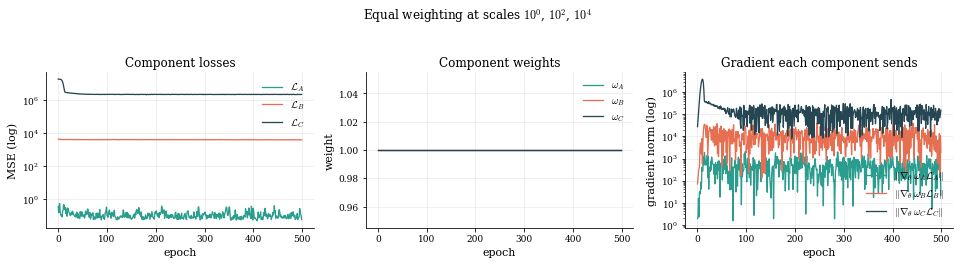

In [7]:
t0 = time.perf_counter()
model_equal, hist_equal = train(equal_weights, SCALES_SPLIT)
print(f"trained in {time.perf_counter()-t0:.0f}s\n")

rel_equal = relative_errors(model_equal)
RESULTS["equal weights"] = rel_equal
report("equal weights", rel_equal)
report("control (flat scales)", rel_flat)
g = hist_equal["gnorm"][-1]
print(f"\nSame problem, same network, only the units changed:"
      f" the total relative error grew by {rel_equal.sum()/rel_flat.sum():.0f}x.")
print(f"Gradient norms at the end: {g[0]:.1e}, {g[1]:.1e}, {g[2]:.1e}: "
      f"f_C sends {g[2]/g[0]:.0e} times the gradient of f_A.")
worst = "ABC"[int(np.argmax(rel_equal))]
print(f"The worst-fit component is f_{worst} at {100*rel_equal.max():.0f}% relative error.")

plot_run(hist_equal, "Equal weighting at scales $10^0$, $10^2$, $10^4$", savename="loss_norm_equal_weights")

The right panel is the one to read. The parameters are shared, and the update they receive is the
sum of three gradients whose norms differ by six orders of magnitude. Whatever $f_A$ and $f_B$ would
like the trunk to do is rounding error against what $f_C$ asks for.

Which component ends up worst is then a matter of which one happens to share the least structure
with $f_C$; it is not necessarily the smallest one. Here it is $f_B$, the oscillatory shape.

---
## 4. Fix 1: non-dimensionalize, then weight equally

Every residual has a natural scale: consumption, output, a marginal utility. Dividing each residual
by that scale before it enters the loss costs nothing and removes the problem at the source.

Dividing every target by its own scale gives back exactly the Section 2 setup, so there is nothing
left to train: the control run *is* the non-dimensionalized run. That equivalence is the point.

In [8]:
model_norm, hist_norm, rel_norm = model_flat, hist_flat, rel_flat
RESULTS["normalized residuals"] = rel_norm

report("normalized residuals", rel_norm)
report("equal weights", rel_equal)
print(f"\nFactor {rel_equal.sum()/rel_norm.sum():.0f}x better on the total relative error,")
print("from a change of units and no new hyperparameter.")

normalized residuals        rel_A =  0.0030   rel_B =  0.0022   rel_C =  0.0031   |   total = 0.0083
equal weights               rel_A =  0.1771   rel_B =  0.5399   rel_C =  0.1162   |   total = 0.8332

Factor 101x better on the total relative error,
from a change of units and no new hyperparameter.


---
## 5. Fix 2: inverse-loss weighting

When the scales are not known in advance, the obvious adaptive rule weights each component by the
inverse of its current magnitude,

$$\bar{\mathcal{L}}_k^{(m)} = \beta\,\bar{\mathcal{L}}_k^{(m-1)} + (1-\beta)\,\mathcal{L}_k^{(m)},
\qquad
\omega_k^{(m)} = \frac{M/(\bar{\mathcal{L}}_k^{(m)} + \epsilon)}{\sum_j 1/(\bar{\mathcal{L}}_j^{(m)} + \epsilon)},$$

so that $\sum_k \omega_k = M$. By construction the *weighted losses* $\omega_k \mathcal{L}_k$ are then
all equal. Look at what that does to the gradients: the gradient of $\omega_k \mathcal{L}_k$ scales
like $\omega_k \cdot \text{scale}_k^2 \cdot e_k \propto 1/e_k$, where $e_k$ is the unit-free error. The
component that is currently fit **best** gets the **largest** gradient. That is the instability the
slides mention, and the panel below shows it.

trained in 19s

inverse-loss weighting      rel_A =  0.0082   rel_B =  0.0329   rel_C =  0.4070   |   total = 0.4481
equal weights               rel_A =  0.1771   rel_B =  0.5399   rel_C =  0.1162   |   total = 0.8332

Final weights          : w_A = 3.00e+00, w_B = 1.61e-05, w_C = 4.06e-10
Final weighted losses  : 2.79e-04, 3.67e-04, 7.69e-03   (equalized, as designed)
Final gradient norms   : 1.75e-01, 4.76e-03, 4.47e-04

The weights span 7e+09x, but the weighted losses are equal, so the gradient
goes to whichever component is currently best fit. The rule does balance the levels; what
it does not do is give every component a steady share of the update.


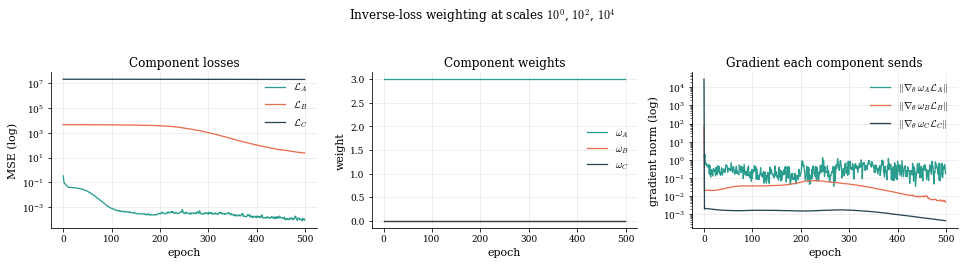

In [9]:
def make_inverse_loss(beta=0.99, eps=1e-8):
    ema = [None, None, None]
    def weights(losses, prev_losses, init_losses, prev_weights, step):
        for k in range(3):
            ema[k] = losses[k] if ema[k] is None else beta*ema[k] + (1-beta)*losses[k]
        raw = [1.0/(ema[k] + eps) for k in range(3)]
        s = sum(raw)
        return [3.0*r/s for r in raw]
    return weights

t0 = time.perf_counter()
model_inv, hist_inv = train(make_inverse_loss(), SCALES_SPLIT)
print(f"trained in {time.perf_counter()-t0:.0f}s\n")

rel_inv = relative_errors(model_inv)
RESULTS["inverse-loss weighting"] = rel_inv
report("inverse-loss weighting", rel_inv)
report("equal weights", rel_equal)
w, L, g = hist_inv["weight"][-1], hist_inv["loss"][-1], hist_inv["gnorm"][-1]
print("\nFinal weights          : " + ", ".join(f"w_{c} = {v:.2e}" for c, v in zip("ABC", w)))
print("Final weighted losses  : " + ", ".join(f"{v:.2e}" for v in w * L) + "   (equalized, as designed)")
print("Final gradient norms   : " + ", ".join(f"{v:.2e}" for v in g))
print(f"\nThe weights span {w.max()/w.min():.0e}x, but the weighted losses are equal, so the gradient")
print("goes to whichever component is currently best fit. The rule does balance the levels; what")
print("it does not do is give every component a steady share of the update.")

plot_run(hist_inv, "Inverse-loss weighting at scales $10^0$, $10^2$, $10^4$", savename="loss_norm_inverse_weights")

---
## 6. Fix 3: ReLoBRaLo, and what limits it

ReLoBRaLo (Bischof and Kraus, 2021) weights by **relative progress** rather than by level. With
$\kappa_{k,s}^{(m)} = \mathcal{L}_k^{(m)} / (T\,\mathcal{L}_k^{(m-1)})$ and
$\kappa_{k,b}^{(m)} = \mathcal{L}_k^{(m)} / (T\,\mathcal{L}_k^{(0)})$,

$$\omega_k^{(m)} = \alpha\Bigl[\rho\,\omega_k^{(m-1)}
   + (1-\rho)\,M\operatorname{softmax}_k(\kappa_{\cdot,b}^{(m)})\Bigr]
   + (1-\alpha)\,M\operatorname{softmax}_k(\kappa_{\cdot,s}^{(m)}).$$

The original draws $\rho \sim \text{Bernoulli}(0.999)$ each step; the classroom version uses the
deterministic blend, which is easier to read and to debug.

Two things limit how far the weights can move, and it pays to keep them apart.

1. **The softmax spread.** For any two components $\hat\omega_j/\hat\omega_k =
   \exp((\kappa_j - \kappa_k)/T)$. Step ratios sit near 1 for every component whatever its scale, and
   baseline ratios lie in $[0,1]$, so at $T = 1$ a single softmax output can separate two weights by
   at most a factor of about $e$. Smaller $T$ raises that ceiling.
2. **The smoothing.** $\alpha = \rho = 0.999$ means each update moves the weight by a tenth of a
   percent of the way to the softmax target: a time constant of about a thousand *updates*. Applied
   once per epoch over 500 epochs, the weights cannot get anywhere near the softmax ceiling, at any
   $T$. Applied once per optimizer step, as the authors do, they can.

Both versions are run below. The prediction for the per-epoch version is that it stays within a few
percent of equal weighting. The per-step version is the real test of what relative balancing can do
against a scale gap that sits in the units.

trained in 40s

ReLoBRaLo, per epoch        rel_A =  0.1769   rel_B =  0.5395   rel_C =  0.1162   |   total = 0.8326
ReLoBRaLo, per step         rel_A =  0.1769   rel_B =  0.5392   rel_C =  0.1162   |   total = 0.8323
equal weights               rel_A =  0.1771   rel_B =  0.5399   rel_C =  0.1162   |   total = 0.8332
normalized residuals        rel_A =  0.0030   rel_B =  0.0022   rel_C =  0.0031   |   total = 0.0083

per epoch: 500 weight updates; final weights [0.975, 1.143, 0.883], spread 1.29x

per step: 7500 weight updates; final weights [0.976, 1.208, 0.816], spread 1.48x

Softmax ceiling at T = 1: about 2.7x. Gap in the units: 1e4 in scale, 1e8 in loss.


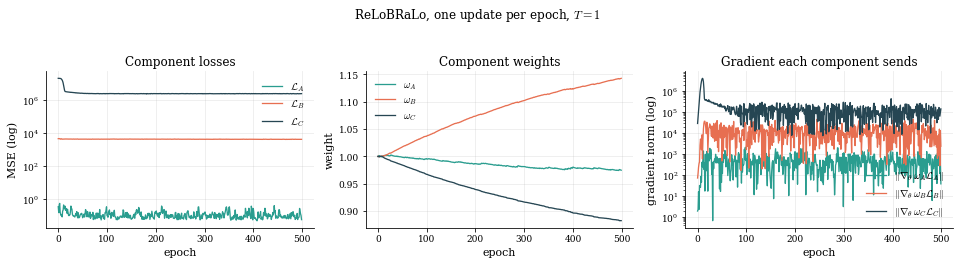

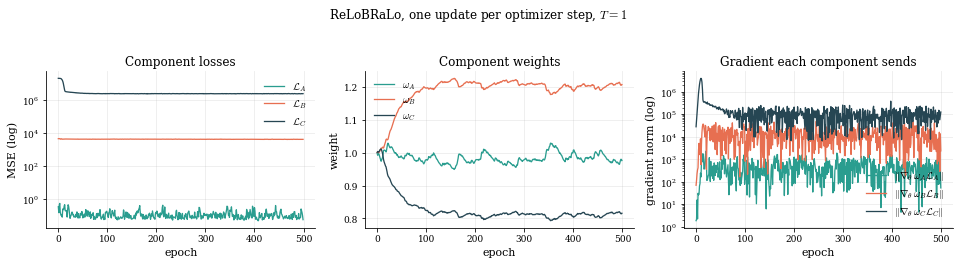

In [10]:
def make_relobralo(T=1.0, alpha_lb=0.999, rho_lb=0.999):
    def weights(losses, prev_losses, init_losses, prev_weights, step):
        eps = 1e-12
        k_step = np.array([losses[k] / (T*prev_losses[k] + eps) for k in range(3)])
        k_base = np.array([losses[k] / (T*init_losses[k] + eps) for k in range(3)])
        e_s = np.exp(k_step - k_step.max()); w_step = 3.0 * e_s / e_s.sum()
        e_b = np.exp(k_base - k_base.max()); w_base = 3.0 * e_b / e_b.sum()
        return [alpha_lb*(rho_lb*prev_weights[k] + (1-rho_lb)*w_base[k])
                + (1-alpha_lb)*w_step[k] for k in range(3)]
    return weights

t0 = time.perf_counter()
model_relo, hist_relo = train(make_relobralo(T=1.0), SCALES_SPLIT)
model_rstep, hist_rstep = train(make_relobralo(T=1.0), SCALES_SPLIT, per_step=True)
print(f"trained in {time.perf_counter()-t0:.0f}s\n")

rel_relo  = relative_errors(model_relo);  RESULTS["ReLoBRaLo, per epoch (T=1)"] = rel_relo
rel_rstep = relative_errors(model_rstep); RESULTS["ReLoBRaLo, per step (T=1)"]  = rel_rstep
report("ReLoBRaLo, per epoch", rel_relo)
report("ReLoBRaLo, per step", rel_rstep)
report("equal weights", rel_equal)
report("normalized residuals", rel_norm)

for tag, h, n_upd in [("per epoch", hist_relo, EPOCHS), ("per step", hist_rstep, EPOCHS * N_BATCHES)]:
    w = h["weight"]
    print(f"\n{tag}: {n_upd} weight updates; final weights ["
          + ", ".join(f"{v:.3f}" for v in w[-1]) + f"], spread {w[-1].max()/w[-1].min():.2f}x")
print(f"\nSoftmax ceiling at T = 1: about {np.e:.1f}x. Gap in the units: 1e4 in scale, 1e8 in loss.")

plot_run(hist_relo,  "ReLoBRaLo, one update per epoch, $T = 1$",         savename="loss_norm_relobralo_weights")
plot_run(hist_rstep, "ReLoBRaLo, one update per optimizer step, $T = 1$", savename="loss_norm_relobralo_step_weights")

### So what is ReLoBRaLo for?

For the case it was designed for: components that are **already on comparable scales** but
converge at different *rates*, a PDE residual that drops quickly while a boundary residual stalls.
There a factor of a few is the right amount of authority, and the relative-progress signal is
informative. The original paper applies it to PINN losses that have been non-dimensionalized first.

Use it after non-dimensionalizing, not instead of it.

  seed 0 done (92s)


  seed 1 done (167s)


  seed 2 done (249s)

rule                        median       min       max   (n = 3 seeds)
--------------------------------------------------------------
equal weights               0.8607    0.8332    0.9241
inverse-loss                0.4481    0.4178    0.6090
ReLoBRaLo, per epoch        0.8610    0.8326    0.9327
ReLoBRaLo, per step         0.8713    0.8323    0.9311
normalized residuals        0.0115    0.0083    0.0181


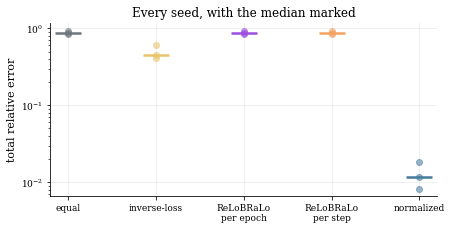

In [11]:
# ----------------------------------------------------------------
# All rules, several seeds, on one scale-free axis
# ----------------------------------------------------------------
RULES = {   # name -> (rule factory, scales, undo, per_step)
    "equal weights":         (lambda: equal_weights,        SCALES_SPLIT, (1.0, 1.0, 1.0),    False),
    "inverse-loss":          (lambda: make_inverse_loss(),  SCALES_SPLIT, (1.0, 1.0, 1.0),    False),
    "ReLoBRaLo, per epoch":  (lambda: make_relobralo(1.0),  SCALES_SPLIT, (1.0, 1.0, 1.0),    False),
    "ReLoBRaLo, per step":   (lambda: make_relobralo(1.0),  SCALES_SPLIT, (1.0, 1.0, 1.0),    True),
    "normalized residuals":  (lambda: equal_weights,        SCALES_FLAT,  tuple(SCALES_SPLIT), False),
}
COLS = [M_COL["equal"], M_COL["inverse"], M_COL["relobralo"], M_COL["relobralo_step"], M_COL["normalized"]]

totals = {name: [] for name in RULES}
t0 = time.perf_counter()
for sd in SEEDS:
    for name, (make, scales, undo, ps) in RULES.items():
        m, _ = train(make(), scales, seed=sd, per_step=ps)
        totals[name].append(relative_errors(m, undo_scale=undo).sum())
    print(f"  seed {sd} done ({time.perf_counter()-t0:.0f}s)")

print(f"\n{'rule':<24s}  {'median':>8s}  {'min':>8s}  {'max':>8s}   (n = {len(SEEDS)} seeds)")
print("-" * 62)
for name in RULES:
    v = np.array(totals[name])
    print(f"{name:<24s}  {np.median(v):8.4f}  {v.min():8.4f}  {v.max():8.4f}")

fig, ax = plt.subplots(figsize=(6.4, 3.3))
for i, (name, c) in enumerate(zip(RULES, COLS)):
    v = np.array(totals[name])
    ax.plot([i]*len(v), v, "o", color=c, ms=6, alpha=0.55)
    ax.plot([i], [np.median(v)], "_", color=c, ms=26, mew=2.5)
ax.set_yscale("log")
ax.set_xticks(range(len(RULES)))
ax.set_xticklabels(["equal", "inverse-loss", "ReLoBRaLo\nper epoch", "ReLoBRaLo\nper step", "normalized"], fontsize=9)
ax.set_ylabel("total relative error")
ax.set_title("Every seed, with the median marked")
fig.tight_layout()
savefig(fig, "loss_norm_method_comparison")
plt.show()

---
## 7. Sensitivity to the temperature $T$

$T$ sets how sharp the softmax is, so it sets the ceiling on how far the weights can separate. The
sweep runs the per-step version, the one whose weights can actually reach that ceiling, on the
mismatched-scale problem, three seeds per temperature. The reading to look for: does any
temperature bring ReLoBRaLo close to the non-dimensionalized level?

T = 0.01    median  0.8658  [0.8317, 1.0356]   final weight spread     4.14x   (60s)


T = 0.1     median  0.8651  [0.8317, 1.0167]   final weight spread     4.04x   (123s)


T = 1       median  0.8713  [0.8323, 0.9311]   final weight spread     1.53x   (193s)


T = 10      median  0.8630  [0.8329, 0.9256]   final weight spread     1.04x   (263s)


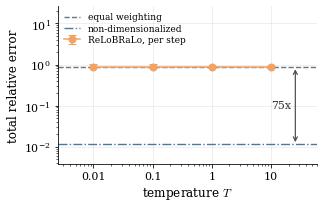


Best temperature 10: median 0.8630, against 0.8607 for equal weighting
and 0.0115 for non-dimensionalized residuals (75x above it).


In [12]:
sweep = {}
t0 = time.perf_counter()
for T in T_SWEEP:
    vals, spreads = [], []
    for sd in SEEDS:
        m_T, h_T = train(make_relobralo(T=T), SCALES_SPLIT, seed=sd, per_step=True)
        vals.append(relative_errors(m_T).sum())
        spreads.append(h_T["weight"][-1].max() / h_T["weight"][-1].min())
    sweep[T] = {"vals": np.array(vals), "spread": float(np.median(spreads))}
    v = sweep[T]["vals"]
    print(f"T = {T:<6g}  median {np.median(v):7.4f}  [{v.min():.4f}, {v.max():.4f}]"
          f"   final weight spread {sweep[T]['spread']:8.2f}x   ({time.perf_counter()-t0:.0f}s)")

Ts   = np.array(list(sweep), dtype=float)
med  = np.array([np.median(sweep[T]["vals"]) for T in sweep])
lo   = np.array([sweep[T]["vals"].min() for T in sweep])
hi   = np.array([sweep[T]["vals"].max() for T in sweep])
eq   = float(np.median(totals["equal weights"]))
nd   = float(np.median(totals["normalized residuals"]))

fig, ax = plt.subplots(figsize=(4.6, 3.0))
ax.axhline(eq, color=M_COL["equal"],      ls="--", lw=1.4, label="equal weighting")
ax.axhline(nd, color=M_COL["normalized"], ls="-.", lw=1.4, label="non-dimensionalized")
ax.errorbar(Ts, med, yerr=[med - lo, hi - med], fmt="o-", color=M_COL["relobralo_step"],
            ms=7, lw=1.5, capsize=4, zorder=3, label="ReLoBRaLo, per step")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylim(min(nd, lo.min()) / 3.0, max(eq, hi.max()) * 25.0)
ax.set_xlim(Ts.min() / 4.0, Ts.max() * 6.0)
ax.set_xticks(Ts); ax.set_xticklabels([f"{t:g}" for t in Ts], fontsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.set_xlabel("temperature $T$", fontsize=12)
ax.set_ylabel("total relative error", fontsize=12)
ax.legend(fontsize=9, loc="upper left", frameon=False, handlelength=1.8, borderpad=0.2, labelspacing=0.25)
xg = Ts.max() * 2.6
ax.annotate("", xy=(xg, eq), xytext=(xg, nd), arrowprops=dict(arrowstyle="<->", color="0.3", lw=1.2))
ax.annotate(f"{eq/nd:.0f}x", xy=(xg, (eq*nd)**0.5), xytext=(-4, 0), textcoords="offset points",
            fontsize=11, color="0.2", va="center", ha="right")
fig.tight_layout()
savefig(fig, "loss_norm_T_sensitivity")
plt.show()

best_T = Ts[int(np.argmin(med))]
print(f"\nBest temperature {best_T:g}: median {med.min():.4f}, against {eq:.4f} for equal weighting")
print(f"and {nd:.4f} for non-dimensionalized residuals ({med.min()/nd:.0f}x above it).")

---
## 8. The same measurement on a DEQN

The Genz experiment put the scale gap in the units, where it is permanent. A DEQN with residuals
written in relative form has no permanent gap, but it does have a **transient** one: at a random
initial policy some conditions are violated by orders of magnitude more than others.

The model is the Brock-Mirman economy with endogenous labour from the Session 2 exercises
(`02_04`, Exercise 2): two policies, the savings rate and hours, and two first-order conditions,
the Euler equation and the intratemporal labour condition $w_t = \psi C_t L_t^\theta$. Each can be
written in **levels** (marginal-utility units and wage units) or in **relative** form (unit-free),
which is what the exercise does:

| | Euler equation | Labour condition |
|:--|:--|:--|
| levels | $1/C_t - \beta\,\mathbb E_t[(1/C_{t+1})(1-\delta+r_{t+1})]$ | $w_t - \psi C_t L_t^\theta$ |
| relative | $1 - 1/(C_t\,\beta\,\mathbb E_t[\cdot])$ | $w_t/(\psi C_t L_t^\theta) - 1$ |

Same network ($2 \times 64$ ReLU, two sigmoid heads), same optimizer, same states (uniform on the
`02_02` box), same seed. Four runs: both formulations with equal weights, and both with
inverse-loss weighting. Recorded every episode: the two losses and the two gradient norms. Scored
at the end: the mean absolute *relative* error of both conditions on 4,096 held-out states, so the
four runs are compared in the same unit-free currency.

  levels, equal  : mean |rel. Euler error| 2.57e-02, mean |rel. labour error| 1.07e-02   (18s)


relative, equal  : mean |rel. Euler error| 2.87e-02, mean |rel. labour error| 6.34e-03   (36s)


  levels, inverse: mean |rel. Euler error| 2.51e-02, mean |rel. labour error| 2.09e-03   (56s)


relative, inverse: mean |rel. Euler error| 3.42e-03, mean |rel. labour error| 1.25e-01   (77s)

run                   gradient-norm ratio, labour / Euler
                       episode 1  episode 30  episode 300     last
levels, equal            2.6e+01     2.3e+02      3.9e+00  3.0e+00
relative, equal          1.2e+05     1.1e+03      3.6e+00  1.0e+00
levels, inverse          2.6e+01     2.7e+00      1.2e+00  7.4e+01
relative, inverse        1.2e+05     2.7e-01      2.7e-01  1.4e+00


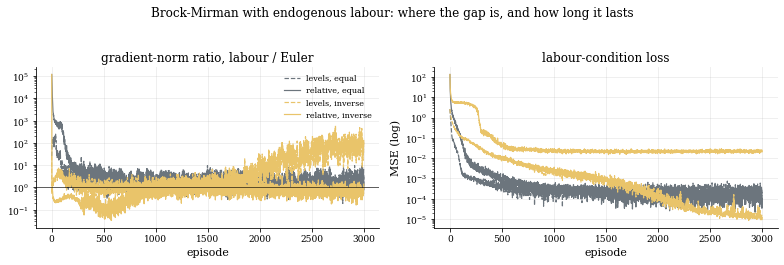

In [13]:
# ---------------------------------------------------------------- model, from 02_04 (Exercise 2)
alpha, beta, delta = 0.36, 0.99, 0.1
sigma_tfp, rho_tfp = 0.04, 0.9
psi, theta = 1.0, 1.0
n_int = 5
_x, _w = np.polynomial.hermite.hermgauss(n_int)
w_int = tf.constant(_w / np.sqrt(np.pi), tf.float32)
x_int = tf.constant(_x * np.sqrt(2.0) * sigma_tfp, tf.float32)
z_lb, z_ub, k_lb, k_ub = 0.7, 1.3, 0.9, 12.0
DEQN_EPISODES = {"smoke": 800, "teaching": 3000, "production": 8000}[RUN_MODE]


def sample_states(n):
    return tf.concat([tf.random.uniform((n, 1), z_lb, z_ub),
                      tf.random.uniform((n, 1), k_lb, k_ub)], axis=1)


def build_policy():
    return keras.Sequential([keras.Input(shape=(2,)), layers.Dense(64, "relu"),
                             layers.Dense(64, "relu"), layers.Dense(2)])


def policies(nn, X):
    o = nn(X)
    return tf.sigmoid(o[:, :1]), 1.01 * tf.sigmoid(o[:, 1:])      # savings rate, hours


def residuals(nn, X):
    """Both first-order conditions, each in levels and in relative form."""
    Z, K = X[:, :1], X[:, 1:]
    s, L = policies(nn, X)
    Y = Z * K**alpha * L**(1.0 - alpha)
    r = alpha * Y / K
    w = (1.0 - alpha) * Y / L
    K1 = (1.0 - delta) * K + Y * s
    Cc = Y * (1.0 - s)
    E = 0.0
    for i in range(n_int):
        Z1 = tf.exp(rho_tfp * tf.math.log(Z) + x_int[i])
        X1 = tf.concat([Z1, K1], axis=1)
        s1, L1 = policies(nn, X1)
        Y1 = Z1 * K1**alpha * L1**(1.0 - alpha)
        C1 = Y1 * (1.0 - s1)
        E = E + w_int[i] * (1.0 / C1) * (1.0 - delta + alpha * Y1 / K1)
    euler_lvl = 1.0 / Cc - beta * E
    euler_rel = 1.0 - 1.0 / (Cc * beta * E)
    lab_lvl   = w - psi * Cc * L**theta
    lab_rel   = w / (psi * Cc * L**theta) - 1.0
    return euler_lvl, euler_rel, lab_lvl, lab_rel


tf.random.set_seed(SEED)
X_hold = sample_states(4096)


def train_deqn(form, rule="equal", episodes=DEQN_EPISODES, seed=SEED, lr=1e-3):
    tf.keras.utils.set_random_seed(seed)
    nn, opt = build_policy(), keras.optimizers.Adam(lr)
    wv = tf.Variable([1.0, 1.0], dtype=tf.float32)

    @tf.function
    def step(X):
        with tf.GradientTape(persistent=True) as tape:
            el, er, ll, lr_ = residuals(nn, X)
            L1 = tf.reduce_mean((el if form == "levels" else er)**2)
            L2 = tf.reduce_mean((ll if form == "levels" else lr_)**2)
            W1, W2 = wv[0] * L1, wv[1] * L2
            total = W1 + W2
        g1 = tape.gradient(W1, nn.trainable_variables)
        g2 = tape.gradient(W2, nn.trainable_variables)
        opt.apply_gradients(zip(tape.gradient(total, nn.trainable_variables), nn.trainable_variables))
        return L1, L2, tf.linalg.global_norm(g1), tf.linalg.global_norm(g2)

    hist, ema = [], None
    for ep in range(episodes):
        out = [float(v) for v in step(sample_states(128))]
        hist.append(out + list(wv.numpy()))
        if rule == "inverse":
            ema = out[:2] if ema is None else [0.99*e + 0.01*o for e, o in zip(ema, out[:2])]
            raw = [1.0/(e + 1e-8) for e in ema]
            wv.assign([2.0*r/sum(raw) for r in raw])
    el, er, ll, lr_ = residuals(nn, X_hold)
    return np.array(hist), (float(tf.reduce_mean(tf.abs(er))), float(tf.reduce_mean(tf.abs(lr_))))


DEQN_RUNS = [("levels", "equal"), ("relative", "equal"), ("levels", "inverse"), ("relative", "inverse")]
deqn = {}
t0 = time.perf_counter()
for form, rule in DEQN_RUNS:
    h, score = train_deqn(form, rule)
    deqn[(form, rule)] = (h, score)
    print(f"{form:>8s}, {rule:<7s}: mean |rel. Euler error| {score[0]:.2e}, "
          f"mean |rel. labour error| {score[1]:.2e}   ({time.perf_counter()-t0:.0f}s)")

print(f"\n{'run':<20s} {'gradient-norm ratio, labour / Euler':>36s}")
print(f"{'':<20s} {'episode 1':>11s} {'episode 30':>11s} {'episode 300':>12s} {'last':>8s}")
for (form, rule), (h, _) in deqn.items():
    ratio = h[:, 3] / h[:, 2]
    print(f"{form + ', ' + rule:<20s} {ratio[0]:>11.1e} {ratio[min(29, len(h)-1)]:>11.1e} "
          f"{ratio[min(299, len(h)-1)]:>12.1e} {ratio[-1]:>8.1e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for (form, rule), (h, _) in deqn.items():
    col = M_COL["equal"] if rule == "equal" else M_COL["inverse"]
    ls  = "-" if form == "relative" else "--"
    axes[0].semilogy(h[:, 3] / h[:, 2], color=col, ls=ls, lw=1.2, label=f"{form}, {rule}")
    axes[1].semilogy(h[:, 1], color=col, ls=ls, lw=1.2)
axes[0].axhline(1.0, color="k", lw=0.6)
axes[0].set_title("gradient-norm ratio, labour / Euler"); axes[0].set_xlabel("episode")
axes[0].legend(frameon=False, fontsize=8)
axes[1].set_title("labour-condition loss"); axes[1].set_xlabel("episode"); axes[1].set_ylabel("MSE (log)")
fig.suptitle("Brock-Mirman with endogenous labour: where the gap is, and how long it lasts", y=1.04)
fig.tight_layout()
savefig(fig, "loss_norm_deqn_labour")
plt.show()

Read the table row by row. At initialization the relative form has the larger gap, because a
random policy puts hours far from their optimum and the unit-free labour residual is large. But the
gap **closes on its own**: the labour condition is intratemporal and easy, its loss falls fast, and
after a few hundred episodes the two conditions send gradients of the same order. Equal weights
survive a transient gap.

Inverse-loss weighting shortens the transient in both forms, and then keeps acting. In levels that
buys the labour condition a better final error at no cost to the Euler equation. In relative form
it over-corrects: once the labour loss is small its weight goes to nearly zero, the Euler equation
gets the whole update, and the labour condition drifts to the worst error of the four runs. A rule
that balances levels has no way of knowing that a small loss is a solved condition rather than a
neglected one.

Contrast the Genz experiment, where the gap is in the units and does not close, ever. The
diagnostic is the same in both cases and it is the one to run on your own model: the ratio of
gradient norms **after** the transient. If it is still $10^3$ at the end, no weighting rule is the
answer; the residual needs different units.

The production example is the IRBC session: `05_01` and `05_02` write the Euler residual relative to
$\lambda$, the aggregate resource constraint as a share of total resources, and the complementarity
residual on the unit-free pair $(\mu/\lambda,\, I/k)$, and then weight them equally.

---
## 9. What to remember

1. **Gradient dominance is measurable.** Record $\|\nabla_\theta\, \omega_k \mathcal{L}_k\|$ per
   component. It costs one extra backward pass per component per epoch and it turns "the network
   ignores $f_A$" from a guess into a number.

2. **Non-dimensionalize first.** Dividing each residual by its natural scale is free, has no
   hyperparameters, and on the Genz testbed beats every adaptive rule by two orders of magnitude.
   In a DEQN this means Euler errors in consumption or marginal-utility units, budget residuals as a
   share of output, complementarity on unit-free pairs.

3. **Inverse-loss weighting balances levels, not gradients.** It equalizes $\omega_k\mathcal{L}_k$,
   which sends the largest gradient to the component that is currently best fit. It helps against a
   transient gap; it is not a fix for a permanent one.

4. **ReLoBRaLo balances progress.** Its softmax over loss ratios has a ceiling of about
   $e^{1/T}$ per update, and the smoothing $\alpha = \rho = 0.999$ needs thousands of updates to get
   there: apply it per optimizer step, after non-dimensionalizing.

5. **A transient gap and a permanent gap look the same at epoch 1.** Only the gradient-norm ratio
   after the transient tells them apart.

### References

- Bischof, R., and Kraus, M. (2021). Multi-objective loss balancing for physics-informed deep
  learning. arXiv:2110.09813. Published in *Computer Methods in Applied Mechanics and Engineering*
  439, 117914 (2025).
- Heydari, A. A., Thompson, C. A., and Mehmood, A. (2019). SoftAdapt. arXiv:1912.12355.
- Chen, Z., Badrinarayanan, V., Lee, C.-Y., and Rabinovich, A. (2018). GradNorm. *ICML*.
- Wang, S., Teng, Y., and Perdikaris, P. (2021). Understanding and mitigating gradient flow
  pathologies in physics-informed neural networks. *SIAM Journal on Scientific Computing* 43(5).

In [14]:
print(f"RUN_MODE = {RUN_MODE}; notebook wall-clock {time.perf_counter()-T_NOTEBOOK:.0f}s")

RUN_MODE = teaching; notebook wall-clock 710s
